In [1]:
# SPDX-License-Identifier: Apache-2.0 AND CC-BY-NC-4.0
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
# http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.


# QML - Quantum Graph Learning: PageRank Through Quantum Stochastic Walks — Solutions
$\renewcommand{\ket}[1]{|#1\rangle}\renewcommand{\bra}[1]{\langle#1|}$

---

**What You Will Do:**

* Build a PageRank transition matrix for a small directed network.
* Implement continuous-time classical PageRank and verify probability conservation.
* Connect a classical master equation to Lindblad evolution of a density matrix.
* Complete and run a guided Quantum PageRank calculation with CUDA-Q Dynamics.
* Compare classical and quantum-stochastic rankings on small and larger graphs.

**Prerequisites:**

* Python, NumPy, and basic matrix multiplication
* Probability distributions and eigenvector intuition
* Familiarity with quantum states and density matrices; review CUDA-Q Academic's [Quick Start to Quantum Computing](https://github.com/NVIDIA/cuda-q-academic/tree/main/quick-start-to-quantum) if needed
* Familiarity with quantum walks; see CUDA-Q Academic [Quantum Walks, Part 1](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-applications-to-finance/01_quantum_walks.ipynb) and [Part 2](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-applications-to-finance/02_quantum_walks.ipynb)
* Optional open-system background from CUDA-Q Academic [Quantum Dynamics 101](https://github.com/NVIDIA/cuda-q-academic/tree/main/dynamics101)
* Optional supervised-learning context from CUDA-Q Academic's [Introduction to Hybrid Quantum Neural Networks](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-machine-learning-and-data-analysis/01_an_introduction_to_hybrid_quantum_neural_networks.ipynb); it is not required

**Key Terminology:**

* Directed graph
* Transition matrix
* Teleportation
* Stationary distribution
* Density matrix
* Hamiltonian
* Lindblad operator
* Quantum stochastic walk

**CUDA-Q Syntax:**

* [`operators.define`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html) — registers a custom matrix operator
* [`operators.instantiate`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html) — creates an operator acting on specified degrees of freedom
* [`cudaq.State.from_data`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.State.from_data) — initializes a CUDA-Q state from array data
* [`cudaq.evolve`](https://nvidia.github.io/cuda-quantum/latest/api/languages/python_api.html#cudaq.evolve) — evolves a closed or open quantum system

**Solutions edition:** Complete implementations are provided in this notebook.

> **Solutions edition:** Every student implementation region is currently completed and marked
> with either **STUDENT TASK (solution shown)** or matching **TODO** / **TODO END** markers. A
> separate student/solutions pair can be produced after review.

**Exercise:** [../04_quantum_pagerank.ipynb](../04_quantum_pagerank.ipynb)



<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 12px 15px 12px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900;">&#9889; GPU Required:</span>** The classical exercises run on a CPU.
The worked quantum-stochastic-walk section requires an NVIDIA GPU for CUDA-Q's `dynamics` target.

</div>


In [2]:
## Instructions for Google Colab. You can ignore this cell if you have CUDA-Q
## set up locally with all required files on your system.
## Uncomment the lines below and execute this cell to install CUDA-Q.

#!pip install cudaq -q
#!pip install -q numpy matplotlib networkx scipy
#
#!wget -q https://github.com/NVIDIA/cuda-q-academic/archive/refs/heads/main.zip
#!unzip -q main.zip
#!mv cuda-q-academic-main/quantum-machine-learning-and-data-analysis/images ../images


> **Note:** Run the cell below to import all required packages.
> If you installed packages above, restart the kernel first
> (**Runtime → Restart session** in Colab, or **Kernel → Restart** in Jupyter).


In [3]:
# Standard library
import uuid
from time import perf_counter

# Scientific computing
import numpy as np

# Graphs and visualization
import matplotlib.pyplot as plt
import networkx as nx

# CUDA-Q
import cudaq
from cudaq import Schedule, ScipyZvodeIntegrator, operators

np.set_printoptions(precision=4, suppress=True)
print(f"CUDA-Q: {cudaq.__version__}")
print(f"NetworkX: {nx.__version__}")


CUDA-Q: CUDA-Q Version 0.15.1 (https://github.com/NVIDIA/cuda-quantum aca5853a76d499ecc3d5f97c2e06163ae99d9c75)
NetworkX: 3.6.1


---
## 1. What Is PageRank, and How Does It Fit Within QML?

### What question does PageRank answer?

Many scientific datasets are naturally represented as **networks**. Web pages are connected
by hyperlinks, papers by citations, and people by social relationships. Once we have such a
network, a common question is: **which nodes are the most important?**

Simply counting the links into a node is often not enough. A link from a well-connected,
influential node should usually carry more evidence than a link from an isolated one.
PageRank captures this recursive idea: a node is important when it is supported by other
important nodes. It assigns every node a score that summarizes both the number and the
quality of the connections leading to it.

PageRank was developed as part of an early Google search engine to identify authoritative web
pages from hyperlink structure. Its importance extends beyond web search: PageRank and its
variants can be applied whenever relationships form a graph and the connections carry some
notion of endorsement, influence, or flow. Examples include citation networks, social and
communication networks, biological networks, and recommendation systems. In each case, the
meaning of a link changes, but the central question remains the same: which nodes are made
important by their position in the network?

### From PageRank to Quantum PageRank

Classical PageRank treats importance as probability flowing through a graph. [Quantum PageRank](https://doi.org/10.1038/srep00605)
keeps that graph-based objective but represents the evolving information with a quantum state.
A **quantum stochastic walk** combines directed, probability-like transitions with coherent
quantum evolution. The coherent part allows different paths through the network to interfere;
the stochastic part retains the directed flow that makes PageRank meaningful. At the end, the
populations of the quantum state are read as node-importance scores.

This notebook is based on Sánchez-Burillo *et al.*, [*Quantum Navigation and Ranking in
Complex Networks*](https://doi.org/10.1038/srep00605). In the networks studied in that paper,
the proposed quantum-classical walk showed several potential benefits:

- **Fewer navigation steps to convergence:** a moderate quantum contribution sometimes reached
  a stable ranking in fewer steps than the classical walk.
- **Finer ranking resolution:** quantum coherence separated nodes that received the same, or
  nearly the same, classical importance.
- **Additional structural information:** interference revealed hierarchy among less-prominent
  nodes that was hidden by the classical ranking.

These are proposed benefits in convergence behavior and the information contained in the
ranking; they are not evidence of a demonstrated computational speedup on quantum hardware.
In this notebook, the immediate goal is to learn about the pagerank algorithm and the intuition behind the quantum version, coded using CUDA-Q Dynamics.

### How does PageRank fit under QML?

The [Introduction to Hybrid Quantum Neural Networks](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-machine-learning-and-data-analysis/01_an_introduction_to_hybrid_quantum_neural_networks.ipynb)
provides a familiar example of **supervised** learning: it uses labeled examples to train
parameters and then apply the trained model to make predictions. PageRank has no labels and no
target answers. It discovers
structure already present in the graph, so it fits a broad definition of **unsupervised**
learning. More specifically, it is a non-parametric quantum graph-inference method rather
than an approach in which a reusable model is trained.


---
## 2. Technical Foundations: How Does Importance Flow?

Consider a five-page miniature web represented as a **directed graph**:

- A links to B and C.
- B links to C.
- C links back to A.
- D links to C and E.
- E links to C.

A page becomes important when important pages send probability to it. This recursive idea is
stronger than merely counting incoming links. Before learning the calculation, Exercise 1
asks you to reason from the network alone and make a prediction.


In [4]:
def make_mini_web():
    graph = nx.DiGraph()
    graph.add_edges_from([
        ("A", "B"), ("A", "C"),
        ("B", "C"),
        ("C", "A"),
        ("D", "C"), ("D", "E"),
        ("E", "C"),
    ])
    return graph


mini_web = make_mini_web()
mini_nodes = list(mini_web.nodes())
mini_position = {
    "A": (-1.0, 0.4),
    "B": (0.0, 1.0),
    "C": (0.9, 0.25),
    "D": (-0.8, -0.8),
    "E": (0.5, -0.9),
}

print("Nodes:", mini_nodes)
print("Directed edges:", list(mini_web.edges()))


Nodes: ['A', 'B', 'C', 'D', 'E']
Directed edges: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('C', 'A'), ('D', 'C'), ('D', 'E'), ('E', 'C')]


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 1: Predict the highest- and lowest-ranked pages</span>**

Use the explorer below to complete four short investigations:

1. Use only the arrows to predict the **highest-** and **lowest-ranked** pages.
2. Reveal the computed result, then apply $P$ one step at a time. Describe how the bright nodes
   change as probability moves from $p^{(0)}$ toward the stationary distribution.
3. Run to convergence. What visual evidence tells you that the distribution has stopped changing?
4. Select at least two source pages and compare their columns in $L$, $T$, and $P$.

You do not need to know how PageRank is calculated yet; this is a preview of the ideas that the
next section develops carefully.

</div>



---
## 3. Classical PageRank in Continuous Time

### 3.1 What does the PageRank matrix do?

PageRank ultimately assigns one score to every node. Collect those scores in a probability
vector $p$, where $p_i$ is the importance assigned to node $i$.

The **PageRank matrix** $P$ is the rule for one step of probability flow through the graph:

$$
p^{(k+1)} = Pp^{(k)}.
$$

An entry $P_{ij}$ answers a concrete question:

> If the walker is currently at source node $j$, what is the probability that the next step
> arrives at destination node $i$?

We therefore use the **column-stochastic** convention: columns are sources, rows are
destinations, every entry is nonnegative, and every column sums to one.

We begin with a **uniform initial distribution** because, before looking at the links, we have
no reason to favor one page over another. For this five-page example,

$$
p^{(0)} = \frac{1}{5}\begin{bmatrix}1 & 1 & 1 & 1 & 1\end{bmatrix}^{\mathsf T}
= \begin{bmatrix}0.2 & 0.2 & 0.2 & 0.2 & 0.2\end{bmatrix}^{\mathsf T}.
$$

This is a neutral starting guess, not an assumption about the final ranking. For the damped
PageRank matrix used here, repeatedly applying $P$ converges to the same stationary
distribution from any normalized starting distribution. The quantum calculation later uses
the analogous unbiased initial state, $\rho(0)=I/N$.

Repeatedly applying $P$ redistributes probability until the distribution stops changing. The
stationary vector $p_*$ satisfies

$$
Pp_* = p_*.
$$

That stationary vector is the PageRank result. Nodes that receive more long-run probability
receive larger importance scores. This is why constructing $P$ correctly is the central
classical task in this lesson.

### 3.2 How do we build $P$?

The graph definition stores only nodes and unweighted directed edges; it does **not** contain
transition probabilities. We create those probabilities in two parts:

$$
P = \alpha L + (1-\alpha)T.
$$

- $L$ is the **link-following matrix**. Imagine someone who is already reading page $j$ and
  clicks one of the hyperlinks shown on that page. The $j$th column of $L$ divides that
  reader's probability equally among the pages that can be reached by those outgoing links.
- $T$ is the **teleportation matrix**. Sometimes the next page is not reached through a link
  on the current page: a person might open a new browser tab, type an address, choose a
  bookmark, or use a search engine. Our simple model represents that fresh browsing action as
  an equal-probability jump to any of the $N$ pages, so every entry of $T$ is $1/N$.
- $\alpha$ balances the two behaviors. With $\alpha=0.85$, a step follows links with
  probability $0.85$ and teleports with probability $0.15$.

Both pieces are needed. $L$ preserves the web's meaningful link structure: a link acts like a
recommendation from one page to another. $T$ keeps the model from getting stuck on a page with
no outgoing links or circulating forever inside a closed group of pages. The mixture makes
every page reachable and gives a stable ranking, while still letting the link structure supply
most of the signal.

Exercise 2 builds these pieces one at a time. Each student edit corresponds directly to one
part of this equation.


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 2: Build and solve PageRank in four steps</span>**

Complete the marked lines across four conceptual steps:

1. Normalize each source column to construct the link-following matrix $L$.
2. Construct the uniform teleportation matrix $T$.
3. Combine them as $P=\alpha L+(1-\alpha)T$.
4. Repeatedly apply $p^{(k+1)}=Pp^{(k)}$ until the distribution converges.

The surrounding code handles bookkeeping and checks. The learning goal is to connect each
line of code to one conceptual part of PageRank, from building the transition rule to finding
the ranking it produces.

</div>


#### Step 1: Convert links into probabilities

First form an adjacency matrix with **destination rows** and **source columns**. In a source
column, a 1 marks each outgoing link. Dividing that column by its number of 1s makes it a
probability distribution.

For example, A has two outgoing links, so its column sends $1/2$ to B and $1/2$ to C.
B has only one outgoing link, so it sends probability $1$ to C.

The five-node graph has no dangling nodes. The supplied fallback branch nevertheless handles a
source with no outgoing links by replacing its column with a uniform distribution.


In [5]:
def build_link_matrix(graph, nodelist):
    nodes = list(nodelist)
    number_of_nodes = len(nodes)
    if number_of_nodes == 0:
        raise ValueError("PageRank requires at least one node.")

    # Transpose so columns are sources and rows are destinations.
    adjacency = nx.to_numpy_array(
        graph, nodelist=nodes, dtype=float, weight=None
    ).T
    link_matrix = np.zeros_like(adjacency)

    for source_index in range(number_of_nodes):
        outgoing_count = adjacency[:, source_index].sum()
        if outgoing_count > 0:
            # STUDENT TASK (solution shown): normalize this source column.
            link_matrix[:, source_index] = (
                adjacency[:, source_index] / outgoing_count
            )
        else:
            # A dangling source teleports uniformly rather than trapping probability.
            link_matrix[:, source_index] = 1.0 / number_of_nodes

    return link_matrix


adjacency = nx.to_numpy_array(
    mini_web, nodelist=mini_nodes, dtype=float, weight=None
).T
link_matrix = build_link_matrix(mini_web, mini_nodes)

assert np.allclose(link_matrix.sum(axis=0), 1.0)
print("Node order:", mini_nodes)
print("Link-following matrix L:")
print(link_matrix)
print("Column sums:", link_matrix.sum(axis=0))


Node order: ['A', 'B', 'C', 'D', 'E']
Link-following matrix L:
[[0.  0.  1.  0.  0. ]
 [0.5 0.  0.  0.  0. ]
 [0.5 1.  0.  0.5 1. ]
 [0.  0.  0.  0.  0. ]
 [0.  0.  0.  0.5 0. ]]
Column sums: [1. 1. 1. 1. 1.]


#### Step 2: Add a way to escape traps

Following links alone can trap probability inside a closed part of a graph. PageRank avoids
this by allowing a uniform teleportation step. For $N$ nodes,

$$
T=\frac{1}{N}\mathbf{1}\mathbf{1}^{T}.
$$

Every entry is $1/N$, so every source column assigns the same probability to every
destination. Here $N=5$, so every entry of $T$ is $0.2$.


In [6]:
def build_teleportation_matrix(number_of_nodes):
    if number_of_nodes <= 0:
        raise ValueError("number_of_nodes must be positive.")

    # STUDENT TASK (solution shown): make every destination equally likely.
    return np.ones((number_of_nodes, number_of_nodes)) / number_of_nodes


teleportation = build_teleportation_matrix(len(mini_nodes))

assert np.allclose(teleportation, 1.0 / len(mini_nodes))
assert np.allclose(teleportation.sum(axis=0), 1.0)
print("Teleportation matrix T:")
print(teleportation)


Teleportation matrix T:
[[0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2]
 [0.2 0.2 0.2 0.2 0.2]]


#### Step 3: Mix link-following and teleportation

Now translate the PageRank equation directly into code:

$$
P=\alpha L+(1-\alpha)T.
$$

At $\alpha=0.85$, the link structure supplies 85% of each transition probability and uniform
teleportation supplies 15%. Because both $L$ and $T$ are column-stochastic, their weighted
combination $P$ is also column-stochastic.


In [7]:
def combine_pagerank_matrices(link_matrix, teleportation, alpha):
    if not 0.0 <= alpha <= 1.0:
        raise ValueError("alpha must lie in [0, 1].")
    if link_matrix.shape != teleportation.shape:
        raise ValueError("L and T must have the same shape.")

    # STUDENT TASK (solution shown): translate P = alpha L + (1-alpha) T.
    return alpha * link_matrix + (1.0 - alpha) * teleportation


alpha = 0.85
P = combine_pagerank_matrices(link_matrix, teleportation, alpha)

assert P.shape == (len(mini_nodes), len(mini_nodes))
assert np.all(P >= 0.0)
assert np.allclose(P.sum(axis=0), 1.0)
print("PageRank matrix P:")
print(P)
print("Column sums:", P.sum(axis=0))


PageRank matrix P:
[[0.03  0.03  0.88  0.03  0.03 ]
 [0.455 0.03  0.03  0.03  0.03 ]
 [0.455 0.88  0.03  0.455 0.88 ]
 [0.03  0.03  0.03  0.03  0.03 ]
 [0.03  0.03  0.03  0.455 0.03 ]]
Column sums: [1. 1. 1. 1. 1.]


#### Worked matrices for this graph

For node order $(A,B,C,D,E)$, the three code steps construct

$$
L=
\begin{bmatrix}
0 & 0 & 1 & 0 & 0 \\
\tfrac{1}{2} & 0 & 0 & 0 & 0 \\
\tfrac{1}{2} & 1 & 0 & \tfrac{1}{2} & 1 \\
0 & 0 & 0 & 0 & 0 \\
0 & 0 & 0 & \tfrac{1}{2} & 0
\end{bmatrix},
\qquad
T=\frac{1}{5}
\begin{bmatrix}
1&1&1&1&1\\
1&1&1&1&1\\
1&1&1&1&1\\
1&1&1&1&1\\
1&1&1&1&1
\end{bmatrix}.
$$

Since $(1-\alpha)/N=0.15/5=0.03$,

$$
P=0.85L+0.15T=
\begin{bmatrix}
0.030 & 0.030 & 0.880 & 0.030 & 0.030 \\
0.455 & 0.030 & 0.030 & 0.030 & 0.030 \\
0.455 & 0.880 & 0.030 & 0.455 & 0.880 \\
0.030 & 0.030 & 0.030 & 0.030 & 0.030 \\
0.030 & 0.030 & 0.030 & 0.455 & 0.030
\end{bmatrix}.
$$

Two entries make the construction concrete:

- $P_{CA}=0.85(1/2)+0.03=0.455$: from A, follow its link to C or teleport to C.
- $P_{DA}=0.85(0)+0.03=0.03$: A does not link to D, so only teleportation reaches D.

Before continuing, open the hosted [Quantum PageRank Explorer](https://nvidia.github.io/cuda-q-academic/quantum-machine-learning-and-data-analysis/interactive_widget/pagerank.html). Change the links and teleportation probability, then compare its transition matrix and convergence behavior with the $P$ constructed above.


### 3.3 Apply $P$ until the ranking converges

Complete Step 4 of Exercise 2 by successively applying $p^{(k+1)}=Pp^{(k)}$. Stop when the
change between successive vectors is below $10^{-10}$. Confirm that the final ranking matches
Exercise 1, then compare your scores with NetworkX PageRank as an independent reference.


In [8]:
# Start with no prior preference among pages.
power_p = np.ones(len(mini_nodes), dtype=float) / len(mini_nodes)
power_tolerance = 1e-10
power_max_iterations = 1_000

for power_iteration in range(1, power_max_iterations + 1):
    # STUDENT TASK (solution shown): apply one PageRank step.
    power_p_next = P @ power_p

    # STUDENT TASK (solution shown): measure the change between successive vectors.
    power_change = np.linalg.norm(power_p_next - power_p, ord=1)

    power_p = power_p_next

    # STUDENT TASK (solution shown): stop once the distribution has converged.
    if power_change < power_tolerance:
        break
else:
    raise RuntimeError("Power iteration did not converge.")

power_ranking = sorted(
    zip(mini_nodes, power_p), key=lambda item: item[1], reverse=True
)

# Compare the result with the established NetworkX implementation.
networkx_result = nx.pagerank(
    mini_web,
    alpha=alpha,
    weight=None,
    max_iter=1_000,
    tol=1e-12,
)
networkx_scores = np.array([networkx_result[node] for node in mini_nodes])

assert np.isclose(power_p.sum(), 1.0)
assert np.all(power_p >= 0.0)
assert np.linalg.norm(P @ power_p - power_p, ord=1) < power_tolerance
assert np.allclose(power_p, networkx_scores, atol=1e-9, rtol=0.0)

print(f"\nConverged after {power_iteration} applications of P.")
print("Ranking:", " > ".join(node for node, _ in power_ranking))
print(f"{'Page':<6}{'Our score':>14}{'NetworkX':>14}")
for node, score, reference in zip(mini_nodes, power_p, networkx_scores):
    print(f"{node:<6}{score:>14.9f}{reference:>14.9f}")
print("\nMatches Exercise 1 and NetworkX.")



Converged after 47 applications of P.
Ranking: C > A > B > E > D
Page       Our score      NetworkX
A        0.358468061   0.358468061
B        0.182348926   0.182348926
C        0.386433013   0.386433013
D        0.030000000   0.030000000
E        0.042750000   0.042750000

Matches Exercise 1 and NetworkX.


### 3.4 Continuous-Time PageRank

We can go a step further and reformulate the same PageRank flow as a continuous-time problem. This is **not a
different ranking algorithm** and does not provide an inherent speed advantage for ordinary
PageRank, but it does more easily connect to the quantum implementation we will explore below with CUDA-Q Dynamics. 

The probability vector now becomes a function of time, $p(t)$, and evolves according to

$$
\frac{dp}{dt}=Pp-p.
$$

Both methods have the same stationary condition: $dp/dt=0$ implies $Pp_*=p_*$. If the
time-dependent solution converges, its long-time limit is
$p_{\infty}=\lim_{t\rightarrow\infty}p(t)=p_*$. We use $p_*$ for the stationary PageRank
vector and $p_{\infty}$ only when emphasizing the limiting process.

A forward-Euler step makes the relationship to successive applications of $P$ especially clear:

$$
p_{k+1}=(1-\Delta t)p_k+\Delta t Pp_k.
$$

When $\Delta t=1$, this is exactly the discrete update $p_{k+1}=Pp_k$. When
$0<\Delta t<1$, each update moves only partway toward $Pp_k$, so the numerical trajectory and
number of steps differ even though the final PageRank vector is the same.

<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 15px 15px 15px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 3: Implement continuous-time PageRank</span>**

Complete each region between **TODO** and **TODO END**:

1. Implement the forward-Euler update and stop when successive vectors differ by less than the
   requested tolerance.
2. Test several time steps $\Delta t$ and compare how many iterations each run needs.
3. Plot the first few updates for page C so you can compare the convergence behavior.
4. Check that changing $\Delta t$ changes the trajectory, but not the final vector $p_*$.

</div>


In [9]:
# EXERCISE 3

def continuous_time_pagerank(
    transition_matrix,
    initial_probabilities=None,
    dt=0.1,
    max_steps=10_000,
    tolerance=1e-10,
):
    transition_matrix = np.asarray(transition_matrix, dtype=float)
    number_of_nodes = transition_matrix.shape[0]

    if transition_matrix.shape != (number_of_nodes, number_of_nodes):
        raise ValueError("transition_matrix must be square.")
    if not np.allclose(transition_matrix.sum(axis=0), 1.0):
        raise ValueError("transition_matrix must be column stochastic.")
    if not 0.0 < dt <= 1.0:
        raise ValueError("dt must lie in (0, 1] for this Euler update.")

    if initial_probabilities is None:
        probabilities = np.ones(number_of_nodes) / number_of_nodes
    else:
        probabilities = np.asarray(initial_probabilities, dtype=float).copy()
        if probabilities.shape != (number_of_nodes,):
            raise ValueError("initial_probabilities has the wrong shape.")
        if np.any(probabilities < 0.0) or probabilities.sum() <= 0.0:
            raise ValueError("initial_probabilities must be nonnegative with positive mass.")
        probabilities /= probabilities.sum()

    # Implement dp/dt = P @ p - p and retain the trajectory.
    # TODO
    history = [probabilities.copy()]
    for _ in range(max_steps):
        derivative = transition_matrix @ probabilities - probabilities
        next_probabilities = probabilities + dt * derivative
        history.append(next_probabilities.copy())

        if np.linalg.norm(next_probabilities - probabilities, ord=1) < tolerance:
            probabilities = next_probabilities
            break
        probabilities = next_probabilities
    else:
        raise RuntimeError("PageRank did not converge before max_steps.")
    # TODO END

    probabilities /= probabilities.sum()
    return probabilities, np.asarray(history)


In [10]:
# Change or add step sizes in (0, 1], then rerun this cell and the plot.
# TODO
step_sizes = [1.0, 0.5, 0.1]
# TODO END
step_size_runs = {}

print("Node order:", mini_nodes)
for trial_dt in step_sizes:
    trial_scores, trial_history = continuous_time_pagerank(P, dt=trial_dt)
    step_size_runs[trial_dt] = (trial_scores, trial_history)

    assert np.all(np.isfinite(trial_scores))
    assert trial_scores.min() >= -1e-12
    assert np.isclose(trial_scores.sum(), 1.0)
    assert np.allclose(trial_scores, power_p, atol=1e-9, rtol=0.0)

    print(
        f"dt = {trial_dt:<4g} | steps = {len(trial_history) - 1:>4} | "
        "final p* = "
        + np.array2string(trial_scores, precision=9, floatmode="fixed")
    )

# Keep one run for the classical/quantum comparisons later in the notebook.
reference_dt = step_sizes[-1]
classical_scores, classical_history = step_size_runs[reference_dt]

print("\nEvery final vector matches Section 3.3.")


Node order: ['A', 'B', 'C', 'D', 'E']
dt = 1    | steps =   47 | final p* = [0.358468061 0.182348926 0.386433013 0.030000000 0.042750000]
dt = 0.5  | steps =   36 | final p* = [0.358468061 0.182348926 0.386433013 0.030000000 0.042750000]
dt = 0.1  | steps =  211 | final p* = [0.358468061 0.182348926 0.386433013 0.030000000 0.042750000]

Every final vector matches Section 3.3.


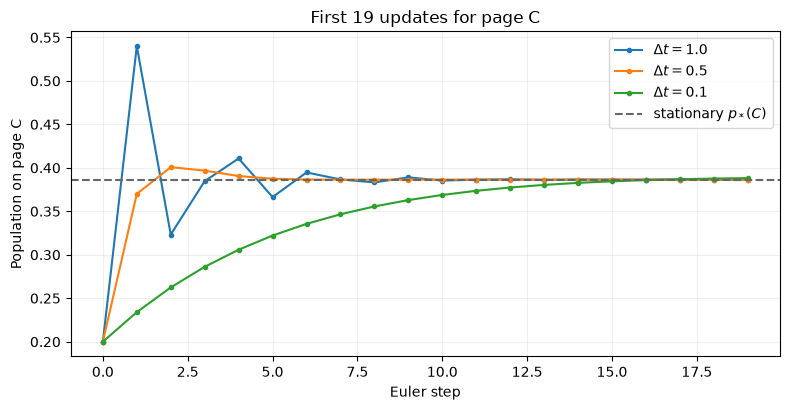

In [11]:
# Plot a zoomed view of one node's early convergence behavior.
# TODO
node_to_plot = "C"
node_index = mini_nodes.index(node_to_plot)
zoom_steps = 20

plt.figure(figsize=(8, 4.2))
for trial_dt, (_, trial_history) in step_size_runs.items():
    number_to_show = min(zoom_steps, len(trial_history))
    plt.plot(
        range(number_to_show),
        trial_history[:number_to_show, node_index],
        marker="o",
        markersize=3,
        label=fr"$\Delta t={trial_dt}$",
    )

plt.axhline(
    power_p[node_index],
    color="#666666",
    linestyle="--",
    label=fr"stationary $p_*({node_to_plot})$",
)
plt.xlabel("Euler step")
plt.ylabel(f"Population on page {node_to_plot}")
plt.title(f"First {zoom_steps - 1} updates for page {node_to_plot}")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
# TODO END


---
## 4. From Classical PageRank to Quantum Evolution

### 4.1 The state we will evolve: the density matrix

Classical PageRank describes the network with a probability vector

$$
p(t)=\begin{bmatrix}p_A(t)&p_B(t)&p_C(t)&p_D(t)&p_E(t)\end{bmatrix}^{\mathsf T},
$$

where $p_i(t)$ is the population—or random-surfer probability—assigned to page $i$. Every
entry is nonnegative and the entries sum to one. Quantum evolution needs a state description
that can hold both populations and quantum coherence. That object is the **density matrix**
$\rho(t)$.

A pure quantum state $|\psi\rangle$ is written as the density matrix
$\rho=|\psi\rangle\langle\psi|$. More generally, if state $|\psi_k\rangle$ occurs with
classical probability $q_k$, we build

$$
\rho=\sum_k q_k\ket{\psi_k}\bra{\psi_k}.
$$

For PageRank, associate each page with a basis state $|A\rangle,\ldots,|E\rangle$. If the
network is in page state $|i\rangle$ with probability $p_i$, then

$$
\rho_{\mathrm{cl}}=\sum_i p_i\ket{i}\bra{i}=\operatorname{diag}(p).
$$

Using the page order A, B, C, D, E, a general density matrix has the explicit form

$$
\rho(t)=
\begin{bmatrix}
\rho_{AA}&\rho_{AB}&\rho_{AC}&\rho_{AD}&\rho_{AE}\\
\rho_{BA}&\rho_{BB}&\rho_{BC}&\rho_{BD}&\rho_{BE}\\
\rho_{CA}&\rho_{CB}&\rho_{CC}&\rho_{CD}&\rho_{CE}\\
\rho_{DA}&\rho_{DB}&\rho_{DC}&\rho_{DD}&\rho_{DE}\\
\rho_{EA}&\rho_{EB}&\rho_{EC}&\rho_{ED}&\rho_{EE}
\end{bmatrix}.
$$

The two kinds of entries have different jobs:

| Entries | What they contain | How PageRank uses them |
|---|---|---|
| Diagonal $\rho_{AA},\ldots,\rho_{EE}$ | Population, or probability of measuring each page | These five numbers are the reported rank scores |
| Off diagonal $\rho_{ij}$, $i\neq j$ | Quantum coherence: relative amplitude and phase between page states | Not rank scores and not joint probabilities; they can influence future populations as the state evolves |

A physical density matrix is Hermitian ($\rho=\rho^\dagger$), positive semidefinite, and
normalized so that $\operatorname{Tr}(\rho)=1$. The trace condition means that the
probabilities of all possible page outcomes sum to one; the trace by itself is **not** a page
score. For more background, see CUDA-Q Academic's [Noisy Simulation notebook](https://github.com/NVIDIA/cuda-q-academic/blob/main/qec101/03_QEC_Noisy_Simulation.ipynb), which develops density matrices and noise channels in more detail.

We now choose the state from which the quantum walk will start. As in the classical calculation,
we initially assign every page the same probability:

$$
p^{(0)}=\frac{1}{N}\begin{bmatrix}1&\cdots&1\end{bmatrix}^{\mathsf T},
\qquad
\rho(0)=\operatorname{diag}(p^{(0)})=\frac{I}{N}.
$$

For our five pages, this is the full initial density matrix

$$
\rho(0)=\frac{I_5}{5}=
\begin{bmatrix}
0.2&0&0&0&0\\
0&0.2&0&0&0\\
0&0&0.2&0&0\\
0&0&0&0.2&0\\
0&0&0&0&0.2
\end{bmatrix}.
$$

Reading the diagonal gives $p^{(0)}=[0.2,0.2,0.2,0.2,0.2]^{\mathsf T}$, while every
off-diagonal coherence is zero. To ask specifically for page A, use the projector
$\Pi_A=|A\rangle\langle A|$. Its projected trace is

$$
p_A^{(0)}=\operatorname{Tr}(\Pi_A\rho(0))=\rho_{AA}(0)=0.2.
$$

> **Notation check:** $p_A^{(0)}$ is the initial score for page A. It is not $P_{AA}$, which
> denotes the A-to-A entry of the transition matrix and equals $0.03$ in this example. Also,
> $\operatorname{Tr}(\rho(0))=1$ only checks normalization; page scores come from the
> projected traces $\operatorname{Tr}(\Pi_i\rho)$.

Many density matrices can have this same diagonal and therefore produce the same page-basis
measurement probabilities at this instant. They can nevertheless have different off-diagonal
coherences, which may change how their populations evolve. The next sections study that role.


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 12px 15px 12px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 4: Same page measurements, different density matrix</span>**

Construct a valid $5\times5$ density matrix $\rho_{\mathrm{candidate}}$ that is **not**
$I_5/5$, but gives the same page-basis probabilities before any evolution:

$$
\operatorname{diag}(\rho_{\mathrm{candidate}})=
\begin{bmatrix}0.2&0.2&0.2&0.2&0.2\end{bmatrix}^{\mathsf T}.
$$

Your matrix must be Hermitian, positive semidefinite, and have trace one. After it passes the
checks below, identify which entries make it different from the maximally mixed state. Explain
why an immediate page-basis measurement cannot distinguish the two states, and why their later
evolution might nevertheless differ.

**Hint:** One guaranteed construction is $\rho=|\psi\rangle\langle\psi|$. What magnitudes
must the five amplitudes of $|\psi\rangle$ have so that every diagonal entry is $0.2$? The
relative phases may be chosen freely.

</div>


In [12]:
# EXERCISE 4
dimension = len(mini_nodes)
rho_mixed = np.eye(dimension, dtype=np.complex128) / dimension
target_page_probabilities = np.ones(dimension) / dimension

# TODO: Replace this example with another valid density matrix that has
# the same diagonal as rho_mixed but different off-diagonal entries.
phases = np.array([0.0, np.pi / 3, np.pi / 2, np.pi, 3 * np.pi / 2])
psi_candidate = np.exp(1j * phases) / np.sqrt(dimension)
rho_candidate = np.outer(psi_candidate, psi_candidate.conj())
# TODO END

hermiticity_error = np.linalg.norm(rho_candidate - rho_candidate.conj().T)
trace_error = abs(np.trace(rho_candidate) - 1.0)
minimum_eigenvalue = np.linalg.eigvalsh(rho_candidate).min()
measured_page_probabilities = np.real(np.diag(rho_candidate))
same_page_measurements = np.allclose(
    measured_page_probabilities, target_page_probabilities
)
different_density_matrix = not np.allclose(rho_candidate, rho_mixed)

print("Candidate density matrix:")
print(rho_candidate)
print("\nPage-basis probabilities:", measured_page_probabilities)
print(f"Trace: {np.trace(rho_candidate)}")
print(f"Hermiticity error: {hermiticity_error:.3e}")
print(f"Minimum eigenvalue: {minimum_eigenvalue:.3e}")
print("Different from I/5:", different_density_matrix)

assert rho_candidate.shape == (dimension, dimension)
assert hermiticity_error < 1e-10
assert trace_error < 1e-10
assert minimum_eigenvalue >= -1e-10
assert same_page_measurements
assert different_density_matrix
print("\nValid: different state, same five page measurements.")


Candidate density matrix:
[[ 0.2   +0.j      0.1   -0.1732j  0.    -0.2j    -0.2   -0.j
  -0.    +0.2j   ]
 [ 0.1   +0.1732j  0.2   +0.j      0.1732-0.1j    -0.1   -0.1732j
  -0.1732+0.1j   ]
 [ 0.    +0.2j     0.1732+0.1j     0.2   +0.j      0.    -0.2j
  -0.2   -0.j    ]
 [-0.2   +0.j     -0.1   +0.1732j  0.    +0.2j     0.2   -0.j
   0.    -0.2j   ]
 [-0.    -0.2j    -0.1732-0.1j    -0.2   +0.j      0.    +0.2j
   0.2   +0.j    ]]

Page-basis probabilities: [0.2 0.2 0.2 0.2 0.2]
Trace: (0.9999999999999999+4.5210146509150915e-18j)
Hermiticity error: 4.028e-17
Minimum eigenvalue: -6.259e-17
Different from I/5: True

Valid: different state, same five page measurements.


### 4.2 The equation that evolves the state

Now that we know what $\rho(t)$ represents, we need a rule for calculating how it changes.
The quantum-stochastic-walk master equation supplies that rule. Its right-hand side gives the
**instantaneous rate of change** of $\rho$. A numerical integrator repeatedly evaluates that
rate to generate $\rho(0)\rightarrow\rho(t_1)\rightarrow\cdots\rightarrow\rho(t_f)$.

The model balances a coherent contribution $\mathcal C_H$ and a directed, dissipative
contribution $\mathcal D_P$:

$$
\frac{d\rho}{dt}
=(1-\omega)\,\mathcal C_H(\rho)
+\omega\,\mathcal D_P(\rho),
\qquad 0\leq\omega\leq1.
$$

![Color-coded guide to the coherent and directed, dissipative terms in the quantum-stochastic-walk master equation](../images/master_equation_terms.svg)

The parameter $\omega$ selects three important regimes:

| Regime | Equation | Expected behavior |
|---|---|---|
| $\omega=1$: purely stochastic limit | $d\rho/dt=\mathcal D_P(\rho)$ | The Hamiltonian is off. Diagonal populations reproduce continuous-time classical PageRank and converge to its unique stationary distribution. |
| $\omega=0$: pure quantum walk | $d\rho/dt=\mathcal C_H(\rho)$ | The evolution is closed and unitary. It generally oscillates or is quasiperiodic rather than converging. If $\rho(0)=I/N$, it does not move because $[H,I/N]=0$. |
| $0<\omega<1$: quantum stochastic walk | Both terms contribute | Coherent interactions modify the transient behavior and stationary scores, while dissipation allows the state to relax. |

A pure quantum walk therefore does not normally produce the stationary PageRank used in this
lesson. One can define a different ranking from time-averaged unitary populations, but that is
not the stationary-state construction studied here. We will first construct $\mathcal D_P$ and
verify the classical $\omega=1$ limit, then add the coherent contribution $\mathcal C_H$. At
this point, these symbols are labels; the following sections derive their formulas.


### 4.3 Start with $\omega=1$: directed jumps without $H$

Setting $\omega=1$ removes the Hamiltonian term and leaves

$$
\frac{d\rho}{dt}=\mathcal D_P(\rho).
$$

This half of the equation should feel familiar: it redistributes page populations using the
same transition matrix $P$ as classical PageRank. We build it from directed **jump operators**,
one for each possible source-to-destination transition.

> **Notation warning:** Earlier, $L$ meant the **link-following matrix** used in
> $P=\alpha L+(1-\alpha)T$. Lindblad jump operators are also often called $L_k$ in the
> literature, but they are entirely different objects. To avoid overloading the symbol, this
> lesson keeps $L$ for the link matrix and denotes a jump operator by $J_{ij}$.

Recall that $P_{ij}$ is the one-step probability of moving from source node $j$ to destination
node $i$ in discrete PageRank. In the continuous master equation, we reuse that dimensionless
number as a relative transition-rate coefficient and build the corresponding jump operator as

$$
J_{ij}=\sqrt{P_{ij}}\,\ket{i}\bra{j}.
$$

This construction has three parts:

1. Read the transition probability from **row $i$, column $j$** of $P$.
2. Form $|i\rangle\langle j|$, an otherwise-zero matrix with a 1 in row $i$, column $j$.
   The bra $\langle j|$ selects the source and the ket $|i\rangle$ writes to the destination.
3. Multiply by $\sqrt{P_{ij}}$. The square root is required because the master equation contains
   both $J_{ij}$ and $J_{ij}^{\dagger}$, producing the rate $P_{ij}$.

For example, $P_{CA}=0.455$, so the jump from A to C is

$$
J_{CA}=\sqrt{0.455}\ket{C}\bra{A}
=
\begin{bmatrix}
0&0&0&0&0\\
0&0&0&0&0\\
\sqrt{0.455}&0&0&0&0\\
0&0&0&0&0\\
0&0&0&0&0
\end{bmatrix}.
$$

Its action makes the source-to-destination meaning explicit:

$$
J_{CA}\ket{A}=\sqrt{0.455}\ket{C},
\qquad
J_{CA}\ket{B}=0.
$$

The squared norm of the first result is $0.455$, the coefficient inherited from the transition
probability. Inside the continuous-time generator it sets a relative rate; it is not the
probability that a finite-time evolution makes exactly one A-to-C jump.
However, $J_{CA}$ is not a quantum gate and $J_{CA}|A\rangle$ is not the complete next state.
It is one rate-weighted **gain contribution** inside an open-system equation. Only the sum of
all gain and loss terms defines trace-preserving evolution.


#### The complete dissipator needs both addition and removal

A single expression $J_{ij}\rho J_{ij}^{\dagger}$ adds population at a destination, but by
itself it does not remove population from the source and does not preserve total probability.
The Lindblad **dissipator** pairs every gain term with the required loss term:

$$
\mathcal D_P(\rho)=\sum_{i,j}\left(
J_{ij}\rho J_{ij}^{\dagger}
-\frac{1}{2}\left\{J_{ij}^{\dagger}J_{ij},\rho\right\}
\right).
$$

| Part | Role | Classical interpretation |
|---|---|---|
| $J_{ij}\rho J_{ij}^{\dagger}$ | Gain | Move $P_{ij}p_j$ into destination $i$ |
| $-\tfrac12\{J_{ij}^{\dagger}J_{ij},\rho\}$ | Loss | Remove the corresponding population from source $j$ |

The gain terms add population to destinations, while the loss terms remove the matching amount
from sources. Only their combination preserves $\operatorname{Tr}(\rho)=1$. At $\omega=1$,
the resulting diagonal populations obey the same update law as continuous-time PageRank:
$d p/dt=Pp-p$. Repeated small steps therefore approach the classical PageRank vector $p_*$.

Without the dissipative dynamics here, the quantum walk would likely not converge to a steady state result $p_*$ which we will see in exercise 7 later.

> **Important:** We apply the complete dissipator—every gain term together with every loss
> term. Applying individual $J_{ij}$ matrices one after another is not a valid update and would
> not preserve the trace.

Exercise 5 makes this concrete by building the complete dissipator, intentionally omitting the
loss terms once, and then evolving two different initial density matrices.


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 12px 15px 12px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 5: Build and test the directed dissipator</span>**

Set $\omega=1$, so $H$ has no influence. Complete the dissipator in the next cell by building
every $J_{ij}$ and adding its gain and loss contributions. Then perform three checks:

1. Take one step using only the gain terms. Check the trace and explain why the result is no
   longer a normalized density matrix.
2. Restore the loss terms and verify that one complete step preserves the trace.
3. Repeatedly apply the complete update until convergence, first from $I_5/5$ and then from your
   alternative valid density matrix in Exercise 4. Confirm that both final diagonals equal the
   classical PageRank vector from Exercise 2. Run Exercise 4 first to use your matrix; otherwise
   the code supplies a valid fallback so this exercise can still run independently. Compare the
   printed final density matrices: the diagonals move to PageRank while the initial off-diagonal
   coherences decay. The dissipator changes both kinds of entries, not only the off-diagonals.

</div>


In [13]:
# EXERCISE 5
def pagerank_dissipator(rho, transition_matrix, include_loss=True):
    derivative = np.zeros_like(rho, dtype=np.complex128)

    for i in range(len(rho)):
        for j in range(len(rho)):
            # TODO: Build J_ij = sqrt(P_ij) |i><j|.
            J_ij = np.zeros_like(rho, dtype=np.complex128)
            J_ij[i, j] = np.sqrt(transition_matrix[i, j])
            # TODO END

            # TODO: Add the gain term and, when requested, the loss term.
            derivative += J_ij @ rho @ J_ij.conj().T
            if include_loss:
                J_dagger_J = J_ij.conj().T @ J_ij
                derivative -= 0.5 * (
                    J_dagger_J @ rho + rho @ J_dagger_J
                )
            # TODO END

    return derivative


number_of_pages = len(P)
dt = 0.1
rho_uniform = np.eye(number_of_pages, dtype=np.complex128) / number_of_pages

# Use the student's Exercise 4 state, or the hint construction if needed.
phases = np.linspace(0.0, 2.0 * np.pi, number_of_pages, endpoint=False)
fallback_state = np.exp(1j * phases) / np.sqrt(number_of_pages)
fallback_rho = np.outer(fallback_state, fallback_state.conj())
rho_alternative = globals().get("rho_candidate", fallback_rho)

# First see why the loss term is necessary.
gain_only = rho_uniform + dt * pagerank_dissipator(
    rho_uniform, P, include_loss=False
)
complete = rho_uniform + dt * pagerank_dissipator(rho_uniform, P)
print("Trace with gain only:", np.trace(gain_only).real)
print("Trace with gain and loss:", np.trace(complete).real)


def dissipative_fixed_point(rho):
    # TODO: Apply the complete dissipator until rho stops changing.
    for _ in range(10_000):
        rho_next = rho + dt * pagerank_dissipator(rho, P)
        if np.linalg.norm(rho_next - rho) < 1e-10:
            return rho_next
        rho = rho_next
    # TODO END
    raise RuntimeError("Dissipative evolution did not converge.")


# Calculate the classical reference if Exercise 2 is not in the current kernel.
classical_page_rank = globals().get("power_p", np.ones(number_of_pages) / number_of_pages)
for _ in range(1_000):
    classical_page_rank = P @ classical_page_rank

final_density_matrices = []
for label, initial_rho in [
    ("uniform state", rho_uniform),
    ("Exercise 4 state", rho_alternative),
]:
    final_rho = dissipative_fixed_point(initial_rho.copy())
    final_scores = np.real(np.diag(final_rho))
    final_density_matrices.append(final_rho)

    print(f"\n{label}")
    print("Final density matrix:")
    print(np.round(final_rho.real, 6))
    print("PageRank scores:", final_scores)
    off_diagonal = final_rho - np.diag(np.diag(final_rho))
    print("Off-diagonal norm:", np.linalg.norm(off_diagonal))

    assert np.isclose(np.trace(final_rho), 1.0)
    assert np.allclose(final_scores, classical_page_rank, atol=1e-8)

assert not np.isclose(np.trace(gain_only), 1.0)
assert np.isclose(np.trace(complete), 1.0)
assert np.allclose(
    np.diag(final_density_matrices[0]),
    np.diag(final_density_matrices[1]),
)
print("\nBoth initial states converge to classical PageRank.")


Trace with gain only: 1.1
Trace with gain and loss: 1.0

uniform state
Final density matrix:
[[0.3585 0.     0.     0.     0.    ]
 [0.     0.1823 0.     0.     0.    ]
 [0.     0.     0.3864 0.     0.    ]
 [0.     0.     0.     0.03   0.    ]
 [0.     0.     0.     0.     0.0428]]
PageRank scores: [0.3585 0.1823 0.3864 0.03   0.0428]
Off-diagonal norm: 0.0

Exercise 4 state
Final density matrix:
[[ 0.3585  0.      0.     -0.     -0.    ]
 [ 0.      0.1823  0.     -0.     -0.    ]
 [ 0.      0.      0.3864  0.     -0.    ]
 [-0.     -0.      0.      0.03    0.    ]
 [-0.     -0.     -0.      0.      0.0428]]
PageRank scores: [0.3585 0.1823 0.3864 0.03   0.0428]
Off-diagonal norm: 3.0181752083383695e-10

Both initial states converge to classical PageRank.


### 4.4 Add coherent interactions between pages

The Hamiltonian $H$ lets us add relationships that are not represented by hyperlinks in $P$.
For example, imagine that pages A and E are both recipe websites used by someone planning meals.
They do not link directly to one another, but their similar content means that interest in one may
be correlated with interest in the other. We can use $H$ to model that symmetric affinity.

This adds something that classical PageRank does not have. The Hamiltonian can create
off-diagonal entries in the density matrix—coherences between pages. As the whole state evolves,
those coherences can later influence the diagonal page scores through quantum interference:

$$
\mathcal C_H(\rho)=-i[H,\rho].
$$

For a simple example, couple only A and E:

$$
H=\ket{A}\bra{E}+\ket{E}\bra{A}
=
\begin{bmatrix}
0&0&0&0&1\\
0&0&0&0&0\\
0&0&0&0&0\\
0&0&0&0&0\\
1&0&0&0&0
\end{bmatrix}.
$$

The two matching entries make $H$ Hermitian, as a Hamiltonian must be. This is a modeling choice:
$P$ still describes directed navigation, while $H$ describes an additional symmetric similarity
between pages. We use coupling strength 1 so the effect is visible. In an application, that
strength could come from content similarity or how often users visit both pages, then be
normalized and validated against data.

> A directed adjacency matrix generally cannot be used directly as $H$ because it is not
> Hermitian. For an undirected graph, however, the adjacency matrix is symmetric and therefore
> is a valid Hamiltonian. Symmetrizing a directed adjacency matrix is another possible modeling
> choice, but the single A–E coupling makes the effect easier to see here.

At $\omega=1$, $H$ is switched off and the result is classical PageRank. For
$0<\omega<1$, this extra A–E interaction can change the final scores.


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 12px 15px 12px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 6: Follow the first three coherent steps</span>**

Complete the coherent derivative, then run three rounds at $\omega=0.5$. Each round prints:

- the diagonal population change requested by the dissipative term;
- the diagonal population change requested by the coherent term;
- the A–E off-diagonal coherence; and
- the updated scores with $H$ and with dissipation alone.

Watch for this sequence: the coherent contribution is zero in round 1, creates off-diagonal
coherence in round 2, and begins changing diagonal page scores in round 3. We will save the
long-time stationary comparison for the CUDA-Q evolution later in the notebook.

> `diag(C_H) = 0` does **not** describe the diagonal of $H$. It means that, at that instant,
> the coherent term is not changing the page probabilities.

</div>


In [14]:
# EXERCISE 6
# H couples similar pages A and E, even though no hyperlink joins them.
number_of_pages = len(mini_nodes)
index_A = mini_nodes.index("A")
index_E = mini_nodes.index("E")

H = np.zeros((number_of_pages, number_of_pages), dtype=np.complex128)
H[index_A, index_E] = 1.0
H[index_E, index_A] = 1.0


def coherent_derivative(rho, hamiltonian):
    # TODO: Return C_H(rho) = -i(H rho - rho H).
    return -1j * (hamiltonian @ rho - rho @ hamiltonian)
    # TODO END


omega = 0.5
dt = 0.1
rho_initial = np.eye(number_of_pages, dtype=np.complex128) / number_of_pages
rho_with_H = rho_initial.copy()
rho_dissipative_only = rho_initial.copy()

coherent_diagonal_changes = []
coherences = []

def format_vector(values):
    values = np.asarray(values).copy()
    values[np.abs(values) < 1e-15] = 0.0
    return np.array2string(values, precision=7, suppress_small=False)


for round_number in range(1, 4):
    dissipative_term = pagerank_dissipator(rho_with_H, P)
    coherent_term = coherent_derivative(rho_with_H, H)

    dissipative_change = dt * omega * dissipative_term
    coherent_change = dt * (1.0 - omega) * coherent_term
    rho_with_H = rho_with_H + dissipative_change + coherent_change

    rho_dissipative_only = rho_dissipative_only + dt * omega * (
        pagerank_dissipator(rho_dissipative_only, P)
    )

    coherent_diagonal_changes.append(np.real(np.diag(coherent_change)))
    coherences.append(rho_with_H[index_A, index_E])

    print(f"\nRound {round_number}")
    print("  dissipative population change:", format_vector(
        np.real(np.diag(dissipative_change))
    ))
    print("  coherent population change:  ", format_vector(
        np.real(np.diag(coherent_change))
    ))
    print("  A-E coherence:               ", rho_with_H[index_A, index_E])
    scores_with_H = np.real(np.diag(rho_with_H))
    scores_dissipative_only = np.real(np.diag(rho_dissipative_only))
    print("  scores with H:               ", format_vector(scores_with_H))
    print("  scores, dissipative only:    ", format_vector(
        scores_dissipative_only
    ))
    print("  score difference:            ", format_vector(
        scores_with_H - scores_dissipative_only
    ))

assert np.allclose(H, H.conj().T)
assert np.allclose(coherent_diagonal_changes[0], 0.0)
assert np.allclose(coherent_diagonal_changes[1], 0.0)
assert not np.isclose(coherences[1], 0.0)
assert not np.allclose(coherent_diagonal_changes[2], 0.0)
assert not np.allclose(np.diag(rho_with_H), np.diag(rho_dissipative_only))
assert np.isclose(np.trace(rho_with_H), 1.0)
assert np.isclose(np.trace(rho_dissipative_only), 1.0)



Round 1
  dissipative population change: [ 0.      -0.00425  0.017   -0.0085  -0.00425]
  coherent population change:   [0. 0. 0. 0. 0.]
  A-E coherence:                0j
  scores with H:                [0.2     0.19575 0.217   0.1915  0.19575]
  scores, dissipative only:     [0.2     0.19575 0.217   0.1915  0.19575]
  score difference:             [0. 0. 0. 0. 0.]

Round 2
  dissipative population change: [ 0.0007225 -0.0040375  0.0156081 -0.008075  -0.0042181]
  coherent population change:   [0. 0. 0. 0. 0.]
  A-E coherence:                0.0002125000000000002j
  scores with H:                [0.2007225 0.1917125 0.2326081 0.183425  0.1915319]
  scores, dissipative only:     [0.2007225 0.1917125 0.2326081 0.183425  0.1915319]
  score difference:             [0. 0. 0. 0. 0.]

Round 3
  dissipative population change: [ 0.0013497 -0.0038203  0.0143206 -0.0076713 -0.0041788]
  coherent population change:   [-2.125e-05  0.000e+00  0.000e+00  0.000e+00  2.125e-05]
  A-E coherence:      

---
## 5. Run Quantum PageRank with CUDA-Q Dynamics

We now give the same five-page problem to CUDA-Q Dynamics. CUDA-Q numerically evolves the density
matrix under the Hamiltonian and collapse operators and returns the final state.

The main APIs are:

| CUDA-Q API | Role in this problem |
|---|---|
| `operators.define` and `operators.instantiate` | Turn the matrices $H$ and $J_{ij}$ into CUDA-Q operators |
| `Schedule` | Specify the initial and final evolution times |
| `cudaq.State.from_data` | Load the initial density matrix $I/N$ |
| `collapse_operators` | Supply the directed dissipative jumps to the solver |
| `cudaq.evolve` | Integrate the master equation and return the evolved state |

The next cell is supplied infrastructure: it registers the matrices we already constructed. The
student exercise that follows focuses on the conceptual CUDA-Q choices rather than operator-name
bookkeeping.


In [15]:
cudaq.set_target("dynamics")


def matrix_factory(matrix):
    matrix = np.asarray(matrix, dtype=np.complex128).copy()
    return lambda: matrix


def define_matrix_operator(matrix, dimension, name):
    operators.define(
        name,
        expected_dimensions=[dimension],
        create=matrix_factory(matrix),
    )
    return operators.instantiate(name, [0])


def build_cudaq_model(transition_matrix, hamiltonian_matrix):
    dimension = len(transition_matrix)
    prefix = f"pagerank_{uuid.uuid4().hex[:8]}"

    hamiltonian = define_matrix_operator(
        hamiltonian_matrix, dimension, f"{prefix}_H"
    )

    jumps = []
    for i in range(dimension):
        for j in range(dimension):
            jump_matrix = np.zeros((dimension, dimension))
            jump_matrix[i, j] = np.sqrt(transition_matrix[i, j])
            jumps.append(
                define_matrix_operator(
                    jump_matrix, dimension, f"{prefix}_J_{i}_{j}"
                )
            )

    return {
        "dimension": dimension,
        "hamiltonian": hamiltonian,
        "jumps": jumps,
    }


mini_cudaq_model = build_cudaq_model(P, H)
print(f"Registered {len(mini_cudaq_model['jumps'])} jump operators.")


Registered 25 jump operators.


<div style="background-color: #f9fff0; border-left: 6px solid #76b900; padding: 12px 15px 12px 20px; border-radius: 4px; margin: 15px 0; color: #333;">

**<span style="color: #76b900; font-size: 1.17em;">Exercise 7: Run and batch Quantum PageRank with CUDA-Q</span>**

All mathematical setup is supplied. Your only task is to complete two calls to `cudaq.evolve`.

**Part A — one evolution.** In the first TODO, pass these arguments:

- `hamiltonian`: the weighted Hamiltonian for this $\omega$;
- `dimensions`: `{0: dimension}` for our single $N$-level subsystem;
- `schedule`: the supplied start/stop `Schedule`;
- `initial_state`: the supplied density matrix converted with `cudaq.State.from_data`;
- `collapse_operators`: the weighted jump operators; and
- `integrator`: the supplied `ScipyZvodeIntegrator`.

The completed function is then run at $\omega=1$ to reproduce classical PageRank and at
$\omega=0.5$ to turn on the A–E coherent interaction.

**Part B — a batched convergence study.** In the later TODO, provide the same categories of
arguments, but use the supplied **lists** of Hamiltonians, initial states, and
collapse-operator lists. Request the intermediate states and set `max_batch_size` so CUDA-Q
can evolve several $\omega$ values together.

Notice, for this study, we now start the entire population on node A.  (This is done so H does not commute with the density matrix and we can see the coherent dynamics.)

Once the cell runs, comment on the following:

- Compare the sequential and batched timings.  Does batching provide a speedup?
- Look at the case of $\omega=1$, how does the result compare to the classical pagerank solution?
- How does $0<\omega<1$ impact the final page ranks?
- What do you notice in the case of a pure quantum walk $\omega=0$ which lacks the dissipative terms?

</div>


In [16]:
# EXERCISE 7 — Part A: one CUDA-Q evolution


def weighted_operators(model, omega):
    hamiltonian = (1.0 - omega) * model["hamiltonian"]
    collapse_operators = [np.sqrt(omega) * jump for jump in model["jumps"]]
    return hamiltonian, collapse_operators


def run_cudaq_pagerank(model, omega, stop_time=75.0):
    dimension = model["dimension"]
    hamiltonian, collapse_operators = weighted_operators(model, omega)
    rho_initial = np.eye(dimension, dtype=np.complex128) / dimension
    initial_state = cudaq.State.from_data(rho_initial)
    schedule = Schedule([0.0, stop_time], ["time"])
    integrator = ScipyZvodeIntegrator()

    # TODO: Complete this cudaq.evolve call with the supplied:
    #   hamiltonian, {0: dimension}, schedule, initial_state,
    #   collapse_operators, and integrator.
    result = cudaq.evolve(
        hamiltonian=hamiltonian,
        dimensions={0: dimension},
        schedule=schedule,
        initial_state=initial_state,
        collapse_operators=collapse_operators,
        integrator=integrator,
    )
    # TODO END

    rho_final = np.asarray(result.final_state()).reshape(dimension, dimension)
    scores = np.real(np.diag(rho_final))
    return scores, rho_final


# Validate the classical limit, then turn on the A-E coherent interaction.
scores_omega_1, _ = run_cudaq_pagerank(mini_cudaq_model, omega=1.0)
scores_omega_05, _ = run_cudaq_pagerank(mini_cudaq_model, omega=0.5)

print("Classical PageRank: ", power_p)
print("CUDA-Q, omega=1:  ", scores_omega_1)
print("CUDA-Q, omega=0.5:", scores_omega_05)
print("Change from classical:", scores_omega_05 - power_p)

assert np.allclose(scores_omega_1, power_p, atol=1e-6)
assert np.isclose(scores_omega_05.sum(), 1.0)


Classical PageRank:  [0.3585 0.1823 0.3864 0.03   0.0428]
CUDA-Q, omega=1:   [0.3585 0.1823 0.3864 0.03   0.0428]
CUDA-Q, omega=0.5: [0.2454 0.1343 0.4124 0.03   0.1779]
Change from classical: [-0.113  -0.048   0.026  -0.      0.1351]



Each $\omega$ value defines an independent evolution with the same matrix dimensions and time
schedule. Running these tiny problems one at a time can leave much of the GPU idle and repeats
solver-launch overhead. A batched call lets CUDA-Q advance several density matrices together,
which can use the GPU more effectively and amortize that overhead.

For batching, `cudaq.evolve` receives:

- a list of weighted Hamiltonians;
- a matching list of initial states;
- a matching nested list of collapse operators—one list per $\omega$; and
- `max_batch_size`, which limits how many problems occupy GPU memory at once.

The supplied cell runs a six-value trajectory study sequentially and in batch. Every run starts
from $|A\rangle\langle A|$ rather than $I/N$. This localized state makes the purely coherent
$\omega=0$ dynamics visible; $I/N$ would remain unchanged because it commutes with every $H$.
For $\omega>0$, teleportation in the dissipative term makes the long-time result independent of
this initial choice.

Complete only the batched `cudaq.evolve` call, confirm that both modes agree within the numerical
solver tolerance, and compare their measured wall times. A speedup is not guaranteed: it depends on
the GPU, solver, problem size, number of saved time points, and memory available for the batch.


In [17]:
# EXERCISE 7 — Part B: sequential versus batched convergence study
omega_values = [0.0, 0.5, 0.6, 0.7, 0.8, 1.0]
trajectory_times = np.linspace(0.0, 30.0, 151)
dimension = mini_cudaq_model["dimension"]
rho_localized = np.zeros((dimension, dimension), dtype=np.complex128)
rho_localized[index_A, index_A] = 1.0
trajectory_schedule = Schedule(trajectory_times, ["time"])
integrator_options = {"atol": 1e-9, "rtol": 1e-7}


def run_cudaq_trajectory(model, omega):
    hamiltonian, collapse_operators = weighted_operators(model, omega)
    return cudaq.evolve(
        hamiltonian=hamiltonian,
        dimensions={0: model["dimension"]},
        schedule=trajectory_schedule,
        initial_state=cudaq.State.from_data(rho_localized),
        collapse_operators=collapse_operators,
        integrator=ScipyZvodeIntegrator(**integrator_options),
        store_intermediate_results=cudaq.IntermediateResultSave.ALL,
    )


def population_history(result, dimension):
    return np.asarray([
        np.real(np.diag(np.asarray(state).reshape(dimension, dimension)))
        for state in result.intermediate_states()
    ])


# Time the ordinary sequential trajectory study.
start = perf_counter()
sequential_results = {
    omega: run_cudaq_trajectory(mini_cudaq_model, omega)
    for omega in omega_values
}
sequential_seconds = perf_counter() - start
sequential_histories = {
    omega: population_history(result, dimension)
    for omega, result in sequential_results.items()
}

# Prepare the batched arguments—one model and state per omega.
weighted_models = [
    weighted_operators(mini_cudaq_model, omega)
    for omega in omega_values
]
batched_hamiltonians = [model[0] for model in weighted_models]
batched_collapse_operators = [model[1] for model in weighted_models]
batched_initial_states = [
    cudaq.State.from_data(rho_localized) for _ in omega_values
]
integrator = ScipyZvodeIntegrator(**integrator_options)
batch_limit = len(omega_values)

# TODO: Complete this batched cudaq.evolve call with the supplied:
#   batched_hamiltonians, {0: dimension}, trajectory_schedule,
#   batched_initial_states, batched_collapse_operators, integrator,
#   store_intermediate_results=cudaq.IntermediateResultSave.ALL,
#   and max_batch_size=batch_limit.
start = perf_counter()
batch_results = cudaq.evolve(
    hamiltonian=batched_hamiltonians,
    dimensions={0: dimension},
    schedule=trajectory_schedule,
    initial_state=batched_initial_states,
    collapse_operators=batched_collapse_operators,
    integrator=integrator,
    store_intermediate_results=cudaq.IntermediateResultSave.ALL,
    max_batch_size=batch_limit,
)
batch_seconds = perf_counter() - start
# TODO END

batched_histories = {}
for omega, result in zip(omega_values, batch_results):
    batched_histories[omega] = population_history(result, dimension)

# Sequential and batched adaptive solves need not take identical internal
# time steps. Compare them at the requested output times using a tolerance
# consistent with that independent numerical integration.
comparison_atol = 1e-5
comparison_rtol = 1e-4
for omega in omega_values:
    maximum_difference = np.max(np.abs(
        batched_histories[omega] - sequential_histories[omega]
    ))
    print(
        f"omega={omega:.1f}: maximum sequential/batched difference "
        f"= {maximum_difference:.3e}"
    )
    assert np.allclose(
        batched_histories[omega],
        sequential_histories[omega],
        atol=comparison_atol,
        rtol=comparison_rtol,
    ), (
        f"Sequential and batched trajectories disagree for omega={omega:.1f}; "
        f"maximum difference is {maximum_difference:.3e}."
    )
    assert np.allclose(
        batched_histories[omega].sum(axis=1), 1.0, atol=1e-8
    )

print(f"Sequential sweep: {sequential_seconds:.3f} s")
print(f"Batched sweep:    {batch_seconds:.3f} s")
print(f"Measured speedup: {sequential_seconds / batch_seconds:.2f}x")
print("The plotted batched trajectories agree with the sequential runs.")


omega=0.0: maximum sequential/batched difference = 3.148e-06
omega=0.5: maximum sequential/batched difference = 2.023e-07
omega=0.6: maximum sequential/batched difference = 8.912e-08
omega=0.7: maximum sequential/batched difference = 8.558e-08
omega=0.8: maximum sequential/batched difference = 6.391e-08
omega=1.0: maximum sequential/batched difference = 1.950e-07
Sequential sweep: 11.087 s
Batched sweep:    7.131 s
Measured speedup: 1.55x
The plotted batched trajectories agree with the sequential runs.


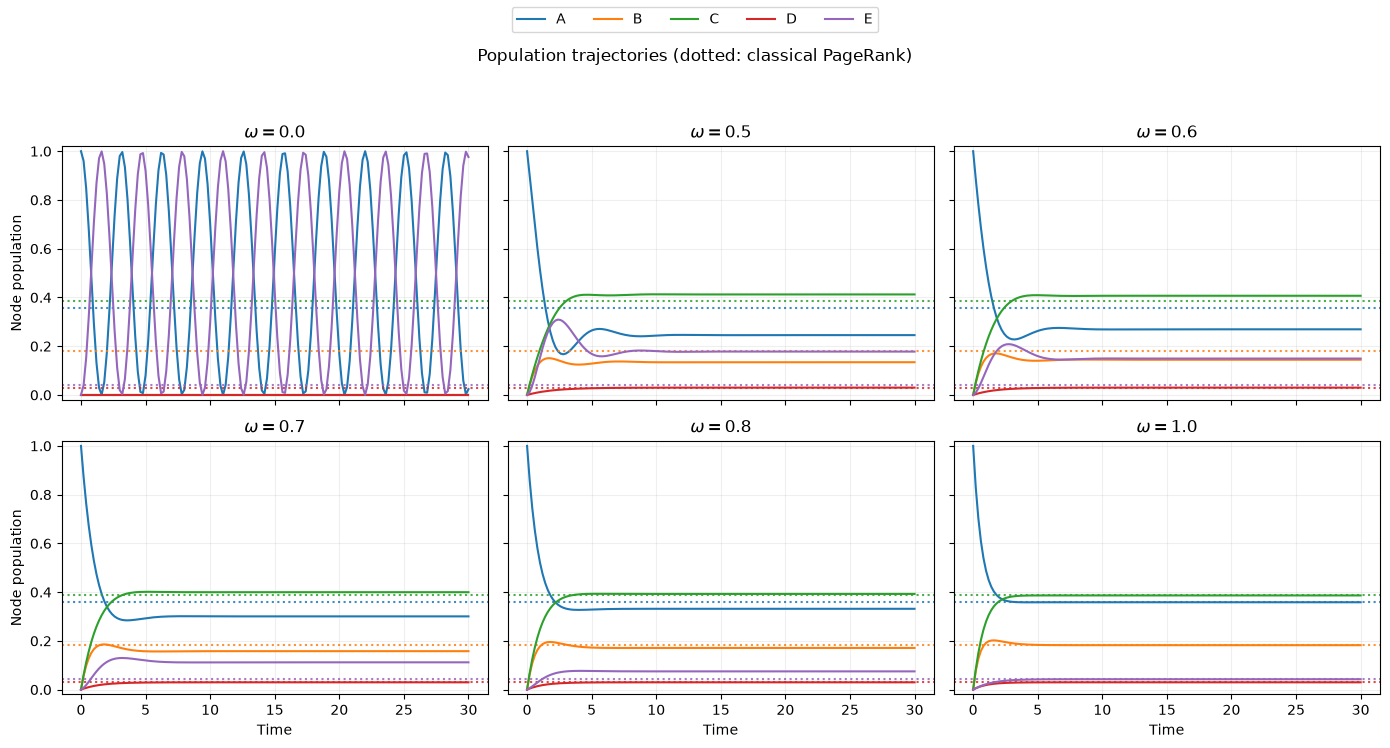

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7.5), sharex=True, sharey=True)
for axis, omega in zip(axes.flat, omega_values):
    history = batched_histories[omega]
    for node_index, node in enumerate(mini_nodes):
        trajectory_line, = axis.plot(
            trajectory_times, history[:, node_index], label=node
        )
        axis.axhline(
            power_p[node_index],
            color=trajectory_line.get_color(),
            linestyle=":",
            linewidth=1.5,
            alpha=0.85,
        )
    axis.set_title(fr"$\omega={omega:.1f}$")
    axis.grid(alpha=0.2)
    axis.set_ylim(-0.02, 1.02)

for axis in axes[-1, :]:
    axis.set_xlabel("Time")
for axis in axes[:, 0]:
    axis.set_ylabel("Node population")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(mini_nodes))
fig.suptitle(
    r"Population trajectories (dotted: classical PageRank)",
    y=0.94,
)
fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.9))
plt.show()


The color-matched dotted lines mark the five classical PageRank scores. At $\omega=1$, every
solid trajectory approaches its corresponding dotted reference. At intermediate $\omega$, the
trajectories converge, but generally to different stationary scores because $H$ is active.

The purely coherent walk at $\omega=0$ does **not** converge. Because $H$ couples A and E,
population oscillates between those two pages under unitary evolution. A finite-dimensional,
closed quantum system generally retains phase information and exhibits oscillatory or
quasiperiodic dynamics rather than relaxing to a unique stationary state.

A time average of those oscillating populations can approach a stable value, but that is a
different ranking definition from the stationary state used by this open-system model.

For every $\omega>0$ shown here, the PageRank dissipator introduces irreversible mixing and the
populations settle to a stationary distribution. In this example, increasing $\omega$
strengthens dissipation and weakens the coherent A–E coupling, so convergence becomes faster
and the final scores move toward classical PageRank. In particular, E receives a larger score at
lower nonzero $\omega$, not at higher $\omega$. A different stationary ranking is expected: it
reflects the additional A–E relationship encoded in $H$ and is not, by itself, evidence that the
ranking is better.

In [the original Quantum Rank study](https://doi.org/10.1038/srep00605), the authors reported
three potential benefits at intermediate mixing values: fewer navigation steps to reach the
stationary state for some network families, separation of nodes tied by classical PageRank, and
finer hierarchy among middle- and lower-ranked nodes while the most central nodes remained
largely stable. These are model-dependent benefits, not a guarantee that every quantum ranking
is more accurate or that it provides a computational speedup.

---
## 6. Apply Quantum PageRank to the Karate Club Network

Until now, each node represented a web page and each edge represented a hyperlink. PageRank is
not restricted to the web, however: the same navigation-based ranking can be applied whenever
relationships form a graph.

Here each node is a member of the Zachary Karate Club and each undirected edge is a friendship.
The graph contains 34 people and 78 friendships. We are asking: **which people occupy the most
structurally important positions in this friendship network?** In the random-walker picture, a
high score means that a walker following friendships is especially likely to be found at that
person's node. This measures network centrality, not a person's authority or social value.

![The 34-node Zachary Karate Club graph. Node size represents the number of friendships.](../images/karate_club_graph.svg)

The graph is undirected, so its adjacency matrix is real and symmetric—and therefore Hermitian.
We use its unweighted adjacency matrix as $H$. In this model, every friendship creates the same
coherent coupling between two members. This is a simple, transparent choice for demonstrating
the method; another application could choose $H$ from similarity data, measured interactions,
or a weighted graph.

> **Runtime note:** After the quick classical setup, the 34-node CUDA-Q evolution below runs
> directly and may take several minutes to complete, depending on the GPU.


In [19]:
karate_graph = nx.karate_club_graph()
karate_nodes = list(karate_graph.nodes())
karate_link_matrix = build_link_matrix(karate_graph, karate_nodes)
karate_teleportation = build_teleportation_matrix(len(karate_nodes))
karate_P = combine_pagerank_matrices(
    karate_link_matrix, karate_teleportation, alpha=0.85
)
karate_H = nx.to_numpy_array(
    karate_graph, nodelist=karate_nodes, dtype=float, weight=None
)
assert np.allclose(karate_H, karate_H.T)  # Hermitian because the graph is undirected
karate_scores, karate_history = continuous_time_pagerank(
    karate_P, dt=0.1
)
karate_networkx = nx.pagerank(
    karate_graph,
    alpha=0.85,
    weight=None,
    max_iter=1_000,
    tol=1e-12,
)
karate_networkx_scores = np.array(
    [karate_networkx[node] for node in karate_nodes]
)

assert np.allclose(
    karate_scores, karate_networkx_scores, atol=1e-9, rtol=0.0
)
assert np.isclose(karate_scores.sum(), 1.0)
print(
    f"Karate Club classical PageRank converged in "
    f"{len(karate_history) - 1} Euler steps."
)
print("Top five nodes:", np.argsort(karate_scores)[-5:][::-1].tolist())


Karate Club classical PageRank converged in 583 Euler steps.
Top five nodes: [33, 0, 32, 2, 1]


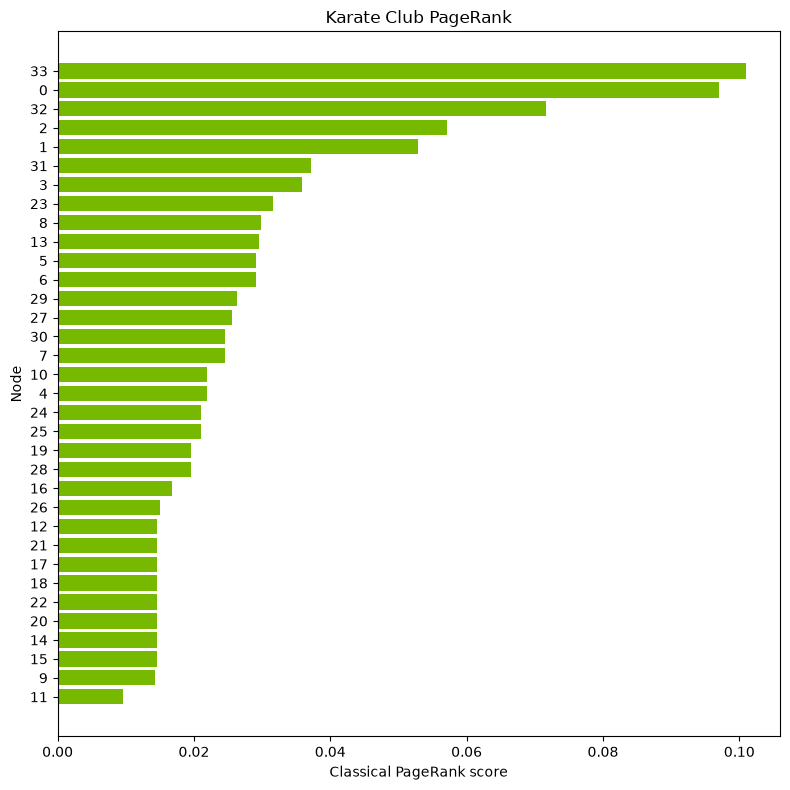

In [20]:
rank_order = np.argsort(karate_scores)
plt.figure(figsize=(8, 8))
plt.barh(
    np.array(karate_nodes)[rank_order].astype(str),
    karate_scores[rank_order],
    color="#76b900",
)
plt.xlabel("Classical PageRank score")
plt.ylabel("Node")
plt.title("Karate Club PageRank")
plt.tight_layout()
plt.show()


In [21]:
karate_model = build_cudaq_model(karate_P, karate_H)
karate_quantum_scores, _ = run_cudaq_pagerank(
    karate_model, omega=0.6, stop_time=25.0
)

print("Large CUDA-Q score sum:", karate_quantum_scores.sum())
print("Top five CUDA-Q nodes:", np.argsort(karate_quantum_scores)[-5:][::-1])


Large CUDA-Q score sum: 1.0000000000000002
Top five CUDA-Q nodes: [33  0 32  2  1]


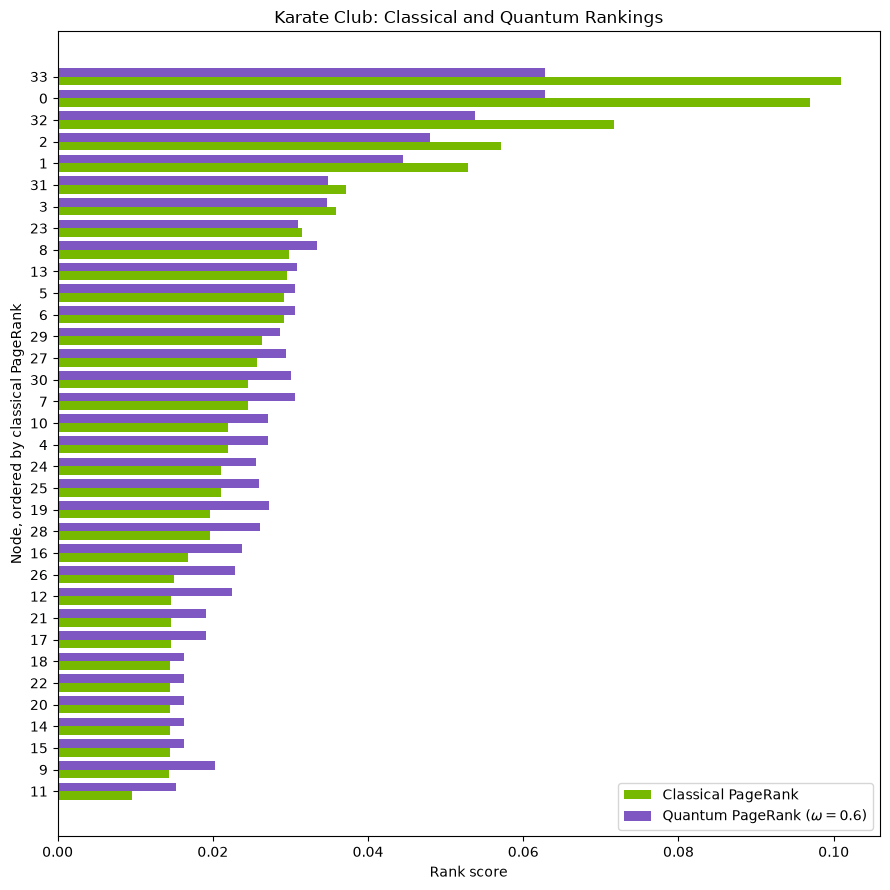

Largest score change: node 33 (-0.03806)


In [22]:
rank_order = np.argsort(karate_scores)
node_labels = np.array(karate_nodes)[rank_order].astype(str)
y = np.arange(len(karate_nodes))
bar_height = 0.4

plt.figure(figsize=(9, 9))
plt.barh(
    y - bar_height / 2,
    karate_scores[rank_order],
    height=bar_height,
    color="#76b900",
    label="Classical PageRank",
)
plt.barh(
    y + bar_height / 2,
    karate_quantum_scores[rank_order],
    height=bar_height,
    color="#7e57c2",
    label=r"Quantum PageRank ($\omega=0.6$)",
)
plt.yticks(y, node_labels)
plt.xlabel("Rank score")
plt.ylabel("Node, ordered by classical PageRank")
plt.title("Karate Club: Classical and Quantum Rankings")
plt.legend()
plt.tight_layout()
plt.show()

largest_change = np.argmax(np.abs(karate_quantum_scores - karate_scores))
print(
    f"Largest score change: node {karate_nodes[largest_change]} "
    f"({karate_quantum_scores[largest_change] - karate_scores[largest_change]:+.5f})"
)


The nodes stay in **classical PageRank order**, so each green–purple pair can be compared
directly. At $\omega=1$, the two bars should overlap. Here $\omega=0.6$ turns on the
adjacency-based Hamiltonian, so differences in the purple bars show how coherent interactions
redistribute the scores. A changed score is not automatically a better ranking; it is the result
of the additional relationships encoded in $H$.


---
## Conclusion

### Key Takeaways

- Quantum PageRank is quantum-enhanced graph inference. It uses quantum dynamics to extract
  structure from one supplied graph, but it does not train a classifier or learn a model that
  generalizes to unseen graphs.
- The classical transition matrix $P$ becomes directed Lindblad jumps, while a Hermitian $H$
  adds coherent relationships. The diagonal of the evolved density matrix is read as the
  node-ranking distribution.
- The $\omega=1$ result must reproduce classical PageRank and provides the essential baseline.
  Values below 1 test how the relationships encoded in $H$ redistribute the scores; a different
  ranking is not automatically a better ranking.
- At $\omega=0$, the walk is purely coherent and generally does not converge to a stationary
  ranking. Nonzero dissipation is what allows this open-system PageRank model to relax.
- CUDA-Q Dynamics let us express the initial density matrix, Hamiltonian, jump operators, time
  schedule, and `cudaq.evolve` call directly. The small convergence study demonstrates GPU
  batching, while the larger Karate problem is run as one simulation.
- GPU density-matrix simulation is a practical way to develop and test a quantum model. It does
  not, by itself, establish quantum computational advantage.

### Agentic AI Extension

Research and implement a gate-based PageRank algorithm using CUDA-Q.


**Related Notebooks:**
* [Introduction to Hybrid Quantum Neural Networks](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-machine-learning-and-data-analysis/01_an_introduction_to_hybrid_quantum_neural_networks.ipynb) — introduces a trainable hybrid QML workflow.
* [Advanced Hybrid Quantum Neural Networks](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-machine-learning-and-data-analysis/02_advanced_hqnns.ipynb) — covers scaling and performance techniques for hybrid models.
* [Quantum Support Vector Machines](https://github.com/NVIDIA/cuda-q-academic/blob/main/quantum-machine-learning-and-data-analysis/03_quantum_svm.ipynb) — explores quantum feature maps for classification.
